   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.4 MB/s eta 0:00:00

Fetching Human (NP_001394193.1)...
  → Human: 393 amino acids
Fetching Mouse (NP_035770.2)...
  → Mouse: 390 amino acids
Fetching Chicken (NP_990595.1)...
  → Chicken: 367 amino acids
Fetching Zebrafish (NP_001258749.1)...
  → Zebrafish: 374 amino acids
Fetching Frog (NP_001001903.1)...
  → Frog: 362 amino acids

All sequences downloaded successfully!

Aligning each species to Human reference...

Mouse aligned to Human — score: 182.0
Chicken aligned to Human — score: -38.5
Zebrafish aligned to Human — score: -53.0
Frog aligned to Human — score: -54.0

Calculating conservation scores per position...

Overall average conservation across all species: 58.7%

Number of highly conserved positions (≥90% identity): 105
Out of total aligned positions: 396



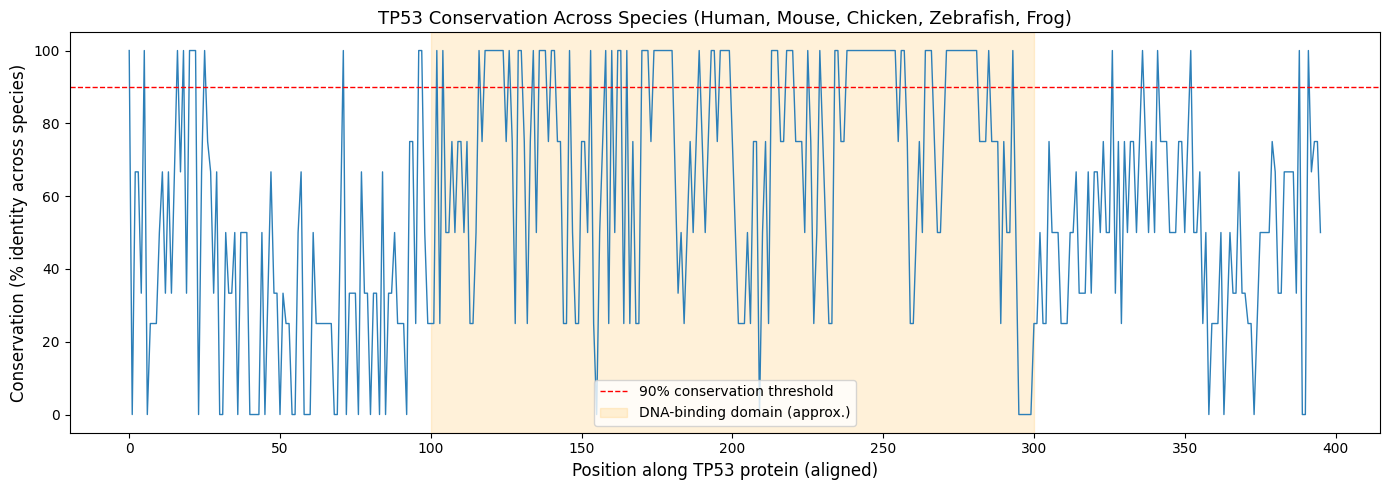


--- Biological Plausibility Check ---
Total species compared: 5
Overall conservation: 58.7%
Highly conserved positions (≥90%): 105 out of 396
Expected: conservation should be higher within positions ~100-300
(the known DNA-binding domain), consistent with published TP53 evolutionary studies.


In [1]:
# ═══════════════════════════════════════════════════════════════════
# RESEARCH QUESTION:
# Which regions of the TP53 tumor suppressor protein are most
# conserved across species (Human, Mouse, Chicken, Zebrafish, Frog)?
# ═══════════════════════════════════════════════════════════════════

# ───────────────────────────────────────────────────────────────────
# STEP 1: Install and import required libraries
# ───────────────────────────────────────────────────────────────────
!pip install biopython -q

from Bio import Entrez, SeqIO, Align
import matplotlib.pyplot as plt

# ───────────────────────────────────────────────────────────────────
# STEP 2: Fetch TP53 protein sequences from NCBI (5 species)
# ───────────────────────────────────────────────────────────────────
Entrez.email = "fatimashahid716@gmail.com"

species_accessions = {
    "Human":     "NP_001394193.1",
    "Mouse":     "NP_035770.2",
    "Chicken":   "NP_990595.1",
    "Zebrafish": "NP_001258749.1",
    "Frog":      "NP_001001903.1"
}

print("Downloading TP53 protein sequences from NCBI...\n")

sequences = {}
for species, accession in species_accessions.items():
    print(f"Fetching {species} ({accession})...")
    handle = Entrez.efetch(db="protein", id=accession, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    sequences[species] = str(record.seq)
    print(f"  → {species}: {len(record.seq)} amino acids")

print("\nAll sequences downloaded successfully!\n")

# ───────────────────────────────────────────────────────────────────
# STEP 3: Align each species to the Human reference sequence
# ───────────────────────────────────────────────────────────────────
print("Aligning each species to Human reference...\n")

aligner = Align.PairwiseAligner()
aligner.mode = 'global'
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5
aligner.match_score = 1
aligner.mismatch_score = -1

human_seq = sequences["Human"]
alignments = {}

for species, seq in sequences.items():
    if species == "Human":
        continue
    alignment = aligner.align(human_seq, seq)[0]
    alignments[species] = alignment
    print(f"{species} aligned to Human — score: {alignment.score}")

print()

# ───────────────────────────────────────────────────────────────────
# STEP 4: Calculate percent identity per position along the protein
# (used to build the conservation plot)
# ───────────────────────────────────────────────────────────────────
print("Calculating conservation scores per position...\n")

alignment_length = len(alignments["Mouse"][0])  # aligned length (with gaps)
conservation_scores = []

for pos in range(alignment_length):
    matches = 0
    total = 0
    for species, alignment in alignments.items():
        ref_char = alignment[0][pos]
        var_char = alignment[1][pos]
        if ref_char != "-" and var_char != "-":
            total += 1
            if ref_char == var_char:
                matches += 1
    score = (matches / total * 100) if total > 0 else 0
    conservation_scores.append(score)

overall_conservation = sum(conservation_scores) / len(conservation_scores)
print(f"Overall average conservation across all species: {overall_conservation:.1f}%\n")

# ───────────────────────────────────────────────────────────────────
# STEP 5: Identify highly conserved positions (≥ 90% identity)
# ───────────────────────────────────────────────────────────────────
highly_conserved_positions = [
    i for i, score in enumerate(conservation_scores) if score >= 90
]

print(f"Number of highly conserved positions (≥90% identity): {len(highly_conserved_positions)}")
print(f"Out of total aligned positions: {alignment_length}\n")

# ───────────────────────────────────────────────────────────────────
# STEP 6: Visualize — Conservation plot along the protein
# ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(conservation_scores, color='#2c7fb8', linewidth=1)
plt.axhline(y=90, color='red', linestyle='--', linewidth=1, label='90% conservation threshold')

# Highlight the known DNA-binding domain region (approx. positions 100-300 in human TP53)
plt.axvspan(100, 300, color='orange', alpha=0.15, label='DNA-binding domain (approx.)')

plt.xlabel('Position along TP53 protein (aligned)', fontsize=12)
plt.ylabel('Conservation (% identity across species)', fontsize=12)
plt.title('TP53 Conservation Across Species (Human, Mouse, Chicken, Zebrafish, Frog)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('tp53_conservation_plot.png', dpi=150)
plt.show()

# ───────────────────────────────────────────────────────────────────
# STEP 7: Biological Plausibility Check
# ───────────────────────────────────────────────────────────────────
print("\n--- Biological Plausibility Check ---")
print(f"Total species compared: {len(sequences)}")
print(f"Overall conservation: {overall_conservation:.1f}%")
print(f"Highly conserved positions (≥90%): {len(highly_conserved_positions)} out of {alignment_length}")
print("Expected: conservation should be higher within positions ~100-300")
print("(the known DNA-binding domain), consistent with published TP53 evolutionary studies.")

In [2]:
# ───────────────────────────────────────────────────────────────────
# STEP 8: Table — Conservation by functional domain
# ───────────────────────────────────────────────────────────────────
import pandas as pd

# Known functional domains of human TP53 (approximate positions)
domains = {
    "Transactivation domain (TAD)": (1, 61),
    "Proline-rich domain":          (62, 94),
    "DNA-binding domain (DBD)":     (95, 312),
    "Tetramerization domain":       (313, 356),
    "C-terminal regulatory domain": (357, 393)
}

domain_results = []

for domain_name, (start, end) in domains.items():
    # conservation_scores list is 0-indexed, positions are 1-indexed
    region_scores = conservation_scores[start-1:end]
    avg_conservation = sum(region_scores) / len(region_scores)
    domain_results.append({
        "Domain": domain_name,
        "Position range": f"{start}-{end}",
        "Avg. conservation (%)": round(avg_conservation, 1)
    })

conservation_table = pd.DataFrame(domain_results)
print(conservation_table.to_string(index=False))

# Save as CSV for the write-up
conservation_table.to_csv("tp53_conservation_by_domain.csv", index=False)

                      Domain Position range  Avg. conservation (%)
Transactivation domain (TAD)           1-61                   41.0
         Proline-rich domain          62-94                   29.8
    DNA-binding domain (DBD)         95-312                   70.3
      Tetramerization domain        313-356                   61.9
C-terminal regulatory domain        357-393                   41.2


In [4]:
# ───────────────────────────────────────────────────────────────────
# STEP 9: Extract DNA-binding domain region and export as FASTA
# (for verification using NCBI BLAST)
# ───────────────────────────────────────────────────────────────────

dbd_start = 95
dbd_end = 312

fasta_lines = []

for species, seq in sequences.items():
    dbd_region = seq[dbd_start-1:dbd_end]  # convert to 0-indexed slicing
    fasta_lines.append(f">{species}")
    fasta_lines.append(dbd_region)

fasta_content = "\n".join(fasta_lines)

# Save to file
with open("tp53_dna_binding_domain.fasta", "w") as f:
    f.write(fasta_content)

# Print so you can copy it directly into NCBI BLAST
print(fasta_content)

>Human
SSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNT
>Mouse
PSQKTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLWVSATPPAGSRVRAMAIYKKSQHMTEVVRRCPHHERCSDGDGLAPPQHLIRVEGNLYPEYLEDRQTFRHSVVVPYEPPEAGSEYTTIHYKYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRDSFEVRVCACPGRDRRTEEENFRKKEVLCPELPPGSAKRALPTCTSAS
>Chicken
RVGFVEAGTAKSVTCTYSPVLNKVYCRLAKPCPVQVRVGVAPPPGSSLRAVAVYKKSEHVAEVVRRCPHHERCGGGTDGLAPAQHLIRVEGNPQARYHDDETTKRHSVVVPYEPPEVGSDCTTVLYNFMCNSSCMGGMNRRPILTILTLEGPGGQLLGRRCFEVRVCACPGRDRKIEEENFRKRGGAGGVAKRAMSPPTEAPEPPKKRVLNPDNEIFY
>Zebrafish
YSPDLNKLFCQLAKTCPVQMVVDVAPPQGSVVRATAIYKKSEHVAEVVRRCPHHERTPDGDNLAPAGHLIRVEGNQRANYREDNITLRHSVFVPYEAPQLGAEWTTVLLNYMCNSSCMGGMNRRPILTIITLETQEGQLLGRRSFEVRVCACPGRDRKTEESNFKKDQETKTMAKTTTGTKRSLVKESSSATLRPEGSKKAKGSSSDEEIFTLQVRGR
>Frog
SVTCTYSTDLNKLFCQLAKTCPLLVRVERPPPLGSILRATAVYKKSEHVAEVVKRCPHHERSVEPGDDPAPPSHLMRVEGNSKA